In [2]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

import sys
import ast

import cassiopeia as cas
import matplotlib.pyplot as plt
import mplscience
import numpy as np
import pandas as pd
import pickle as pic
import scanpy as sc
import seaborn as sns
import squidpy as sq
import tqdm

SPATIAL_PACKAGE="/path/to/spatial/analysis/package"
DATA_DIR="/path/to/kpspatial/dataset/"
sys.path.append(SPATIAL_PACKAGE)

from utilities import target_site_utilities, spatial_utilities

In [4]:
## define sample list
SAMPLES=["B94_04", "B94_20", "B94_23", "B95_24", "B99_22",
        "C12_01", "C12_02", "C12_04", "C12_03", "C12_05",
        "C12_09", "C12_10", "C12_12",
        "C27_11", "M09_01",
        "M09_04", "M09_07", "M09_08",
        "C36_09", "C36_10", "C36_11", "Curio_09",
        "Curio_10", "M09_11", "M09_13", "M09_14",
        "M09_17", "M09_18", "M11_05", "M18_01",
        "M18_02", "M18_04", "C44_06", "C44_08",
        "Curio_001", "M11_06", "M18_06",
        "M11_08", "M18_17", "M11_14",
        "M18_13", "Curio_002", "Curio_003", "Curio_004"
         ]

puck_to_id = pd.read_csv(f"{SPATIAL_PACKAGE}/data/puck_meta.txt", sep='\t', index_col = 0)


puck_to_id.tail(5)

,ID,Mouse,Area,Batch,Slide-seq ID,mESC
Puck,,,,,,
L1_Puck1,S-tags 1,SPC-11,Primary,4,1,m2E1
L2_Puck1,S-tags 2,SPC-11,Primary,4,2,m2E1
L3_Puck1,S-tags 3,SPC-11,Primary,4,3,m2E1
L3_Puck2,S-tags 4,SPC-11,Primary,4,3,m2E1
L4_Puck1,S-tags 5,SPC-11,Primary,4,4,m2E1


### Figure 1b

In [5]:
SAMPLE='M11_08'

filtered_adata = sc.read_h5ad(f"{DATA_DIR}/slideseq/expression/{SAMPLE}_adata.h5ad")
filtered_adata.var_names = filtered_adata.var_names.astype(str)
filtered_adata.var_names_make_unique()

# filtered_adata.obs['tumor_id'] = segmentations.obs.loc[filtered_adata.obs_names, 'tumor_id']
# filtered_adata.obs['tumor_boundary'] = segmentations.obs.loc[filtered_adata.obs_names, 'tumor_boundary']

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
filtered_adata.layers['counts'] = filtered_adata.X.copy()
filtered_adata.layers['logged'] = filtered_adata.X.copy()

sc.pp.normalize_total(filtered_adata, target_sum=1e6)
sc.pp.log1p(filtered_adata, layer='logged')

filtered_adata.layers['scaled'] = filtered_adata.layers['logged'].copy()
sc.pp.scale(filtered_adata, max_value=10, layer='scaled')

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


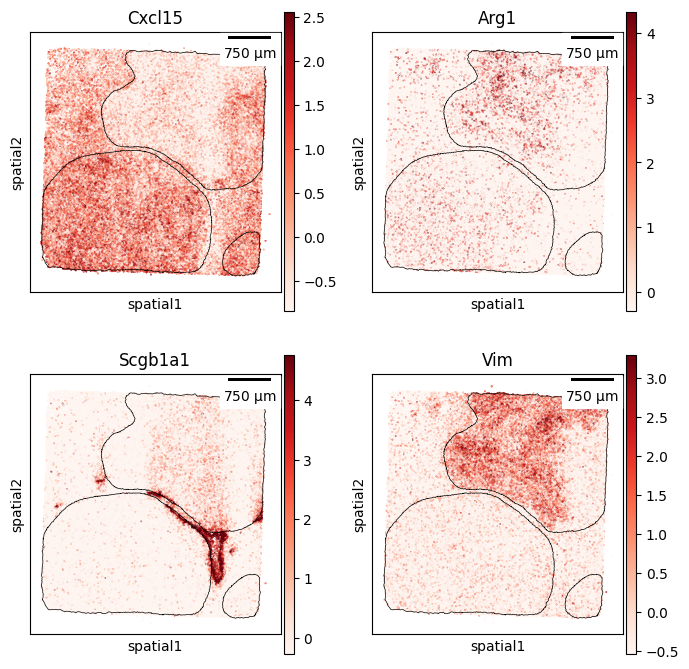

In [7]:
genes = ['Cxcl15', 'Scgb1a1', 'Arg1', 'Vim']

fig, axes = plt.subplots(2, 2, figsize=(7,7))

for gene_i in range(len(genes)):

    gene = genes[gene_i]

    _r, _c = gene_i % 2, gene_i // 2
    _ax = axes[_r, _c]
    
    vals = np.array(filtered_adata[:,gene].layers['scaled'].ravel())
    vmi, vma = np.percentile(vals, 2), np.percentile(vals, 99)
    
    sq.pl.spatial_scatter(
        filtered_adata,
        color=gene,
        cmap='Reds',
        shape=None,
        img=False,
        ax=_ax,
        layer='scaled',
        size=0.2,
        vmin=vmi,
        vmax=vma,
        scalebar_dx=1.0,
        scalebar_units='um',
        scalebar_kwargs={"scale_loc": "bottom", "location": "upper right"},
    )
    for tumor in filtered_adata.obs['tumor_id'].unique():
        if tumor != 'non-tumor':
            spatial_utilities.plot_boundary(filtered_adata, ax=_ax, color='black', tumor_id=tumor, width=0.5)
plt.tight_layout()
plt.show()

## Extended Data Figure 1a

100%|██████████| 44/44 [00:19<00:00,  2.31it/s]


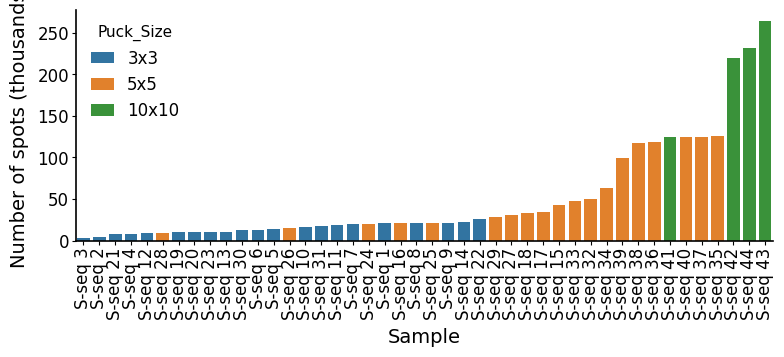

In [15]:
# plot size of dataset
dataset_sizes = []
for puck_name in tqdm.tqdm(SAMPLES):

    # puck_name = experiment.split("/")[-1]
    spatial_adata = sc.read_h5ad(f'{DATA_DIR}/slideseq/expression/{puck_name}_adata.h5ad')

    puck_size = '3x3'
    if 'M' in puck_name:
        puck_size = '5x5'
    if puck_name in ['Curio_001', 'Curio_002', 'Curio_003', 'Curio_004']:
        puck_size = '10x10'

    seq_id = puck_to_id.loc[puck_name, 'ID']
    dataset_sizes.append((seq_id, len(spatial_adata), puck_size))

dataset_summary = pd.DataFrame(dataset_sizes, columns = ['Sample', 'NumCell', 'Puck_Size'])
dataset_summary['NumCell_k'] = dataset_summary['NumCell'] / 1000

with mplscience.style_context():
    fig = plt.figure(figsize=(9, 3))
    ax = plt.gca()
    sns.barplot(dataset_summary.sort_values(by='NumCell_k'), x='Sample', y='NumCell_k', hue='Puck_Size', ax=ax)
    plt.xticks(rotation=90)
    plt.ylabel("Number of spots (thousands)")
    plt.show()

## Extended Data Figrue 1b

100%|██████████| 44/44 [00:19<00:00,  2.29it/s]


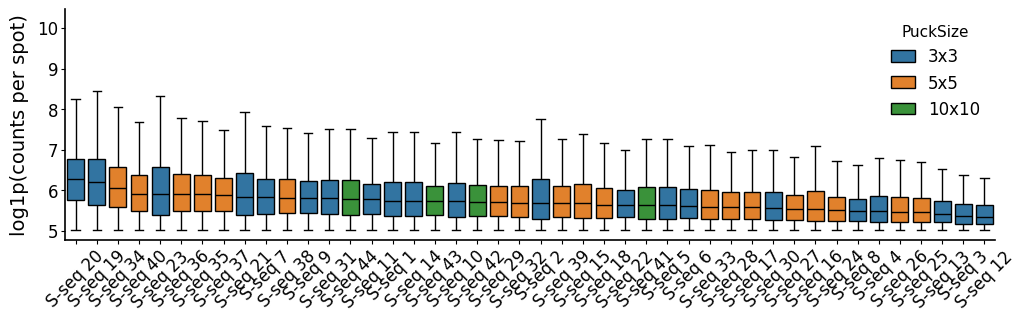

In [16]:
rna_umi_distributions = []
num_spots = 0
num_tumor_sections = 0

for puck_name in tqdm.tqdm(SAMPLES):

    spatial_adata = sc.read_h5ad(f'{DATA_DIR}/slideseq/expression/{puck_name}_adata.h5ad')

    num_spots += len(spatial_adata.obs_names)
    num_tumor_sections += len(spatial_adata.obs.loc[spatial_adata.obs['tumor_id'] != 'non-tumor', 'tumor_id'].unique())

    new_df = pd.DataFrame(spatial_adata.obs[['log1p_total_counts', 'total_counts']].copy())
    new_df['Sample'] = puck_to_id.loc[puck_name, 'ID']
    new_df['cellBC'] = new_df.index.values

    puck_size = '3x3'
    if 'M' in puck_name:
        puck_size = '5x5'
    if puck_name in ['Curio_001', 'Curio_002', 'Curio_003', 'Curio_004']:
        puck_size = '10x10'

    new_df['PuckSize'] = puck_size

    rna_umi_distributions.append(new_df.reset_index())

rna_umi_distribution_total = pd.concat(rna_umi_distributions).reset_index()

_order = rna_umi_distribution_total.groupby('Sample').agg({'total_counts': 'median'}).sort_values(by='total_counts', ascending=False).index
rna_umi_distribution_total['log1p_total_counts'] = np.log1p(rna_umi_distribution_total['total_counts'])

with mplscience.style_context():
    
    h = plt.figure(figsize=(12, 3))
    sns.boxplot(rna_umi_distribution_total, x='Sample', y='log1p_total_counts', hue='PuckSize', order=_order, linecolor='black', fliersize=0)
    plt.xticks(rotation=45)
    plt.xlabel("")
    plt.ylabel("log1p(counts per spot)")
    plt.show()

In [18]:
adata = sc.read_h5ad(f'{DATA_DIR}/slidetags/expression/slidetags_tumor.h5ad')
adata

AnnData object with n_obs × n_vars = 74144 × 4000
    obs: 'tumor', 'batch', 'PercentUncut', 'TS-UMI', 'targetsite', 'total_counts_log', 'n_genes_by_counts', 'pct_counts_ribo', 'pct_counts_mito', 'cell_type'
    var: 'mean', 'std', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'C_scANVI_colors', 'CellType_Remapped_colors', 'Predicted_CellTypes_Consensus_labels_colors', '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'scanvi_leiden2_colors', 'scanvi_leiden_colors', 'scanvi_tumor_colors', 'tech_colors', 'tumor_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap'
    layers: 'counts', 'logged', 'scaled'
    obsp: 'connectivities', 'distances'

## Extended Data Figure 1c

In [5]:
SLIDETAGS_SAMPLES = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9']

rna_to_merge = []
for sample_name in SLIDETAGS_SAMPLES:
    
    filtered_adata = sc.read_h5ad(f"{DATA_DIR}/slidetags/expression/cellbender/{sample_name}_adata_cellbender.h5ad")

    spatial_coordinates = pd.read_csv(f"{DATA_DIR}/slidetags/expression/cellbender/coordinates_df_kptracer_{sample_name}.txt",
                                  sep=' ')

    CB_dictionary = pd.read_csv(f"{SPATIAL_PACKAGE}/data/3M-february-2018.txt.gz", sep='\t', header=None)
    CB_dictionary.columns = ["GEX_CB", "cell_bc"]
    CB_dictionary = CB_dictionary.set_index('cell_bc')['GEX_CB'].to_dict()
    
    spatial_coordinates = spatial_coordinates[spatial_coordinates['number_clusters'] == 1]
    spatial_coordinates['gex_cb'] = spatial_coordinates.apply(lambda x: CB_dictionary[x.cell_bc], axis=1)
    
    spatial_coordinates.set_index('gex_cb', inplace=True)
    
    overlapping_cells = np.intersect1d(filtered_adata.obs_names, spatial_coordinates.index.values)
    
    new_df = pd.DataFrame(filtered_adata.obs['total_counts'].copy())
    new_df['log1p_total_counts'] = np.log1p(new_df['total_counts'])
    new_df['Sample'] = sample_name
    new_df['cellBC'] = new_df.index.values
    new_df['spatial_mapped'] = 'False'
    new_df.loc[overlapping_cells, 'spatial_mapped'] = 'True'
    new_df['tech'] = 'slidetags'

    rna_to_merge.append(new_df)

for sample_name in tqdm.tqdm(['M18_04']):

    spatial_adata = sc.read_h5ad(f'{DATA_DIR}/slideseq/expression/{sample_name}_adata.h5ad')
    
    new_df = pd.DataFrame(spatial_adata.obs[['log1p_total_counts', 'total_counts']].copy())
    new_df['Sample'] = puck_to_id.loc[sample_name, 'ID']
    new_df['cellBC'] = new_df.index.values
    new_df['spatial_mapped'] = 'True'
    new_df['tech'] = 'slideseq'

    rna_to_merge.append(new_df.reset_index())

rna_stats = pd.concat(rna_to_merge)
rna_stats.head(5)

100%|██████████| 1/1 [00:00<00:00,  1.73it/s]


,total_counts,log1p_total_counts,Sample,cellBC,spatial_mapped,tech,index
AGTAGCTAGAATCGTA,19988.0,9.902937,L1,AGTAGCTAGAATCGTA,False,slidetags,NaN
ATTACTCAGTCACGAG,19911.0,9.899078,L1,ATTACTCAGTCACGAG,False,slidetags,NaN
CAATCGAGTCTTAGTG,19925.0,9.899781,L1,CAATCGAGTCTTAGTG,False,slidetags,NaN
AACCAACCACATGTTG,19873.0,9.897168,L1,AACCAACCACATGTTG,True,slidetags,NaN
TAGACCACACATAACC,19838.0,9.895405,L1,TAGACCACACATAACC,True,slidetags,NaN


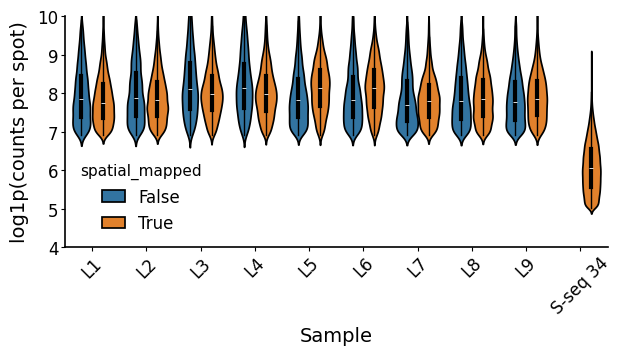

In [24]:
with mplscience.style_context():
    
    h = plt.figure(figsize=(7, 3))
    sns.violinplot(rna_stats, x='Sample', y='log1p_total_counts', linecolor='black', hue='spatial_mapped', inner='box', inner_kws={'box_width': 3},
                   order=['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9', 'S-seq 34'])
    plt.xticks(rotation=45)
    plt.ylabel("log1p(counts per spot)")
    plt.ylim(4, 10)
    plt.show()

### Extended Data Figure 4d

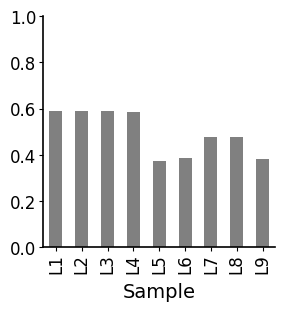

In [7]:
spatial_mapping_stats = (rna_stats.groupby(['Sample', 'spatial_mapped']).size() / rna_stats.groupby(['Sample']).size()).unstack()['True']
spatial_mapping_stats = spatial_mapping_stats.loc[SLIDETAGS_SAMPLES]

with mplscience.style_context():
    h = plt.figure(figsize=(3,3))
    spatial_mapping_stats.plot(kind='bar', color='gray')
    plt.ylim(0, 1)
    plt.show()

## Extended Data Figure 1f

In [28]:
# profile number of conflicting states per spot

all_allele_tables = []

for sample_name in tqdm.tqdm(SAMPLES):

    allele_table = pd.read_csv(f'{DATA_DIR}/slideseq/trees/{sample_name}_allele_table.tsv', sep='\t')
    allele_table = allele_table[~allele_table[['r1', 'r2', 'r3']].isna().any(axis=1)]
 
    # drop alleles without sufficient UMI support
    allele_table = allele_table[allele_table['UMI'] >= 2]

    allele_table['Sample'] = sample_name
    allele_table['dataset'] = 'Slide-seq' 
    all_allele_tables.append(allele_table)

combined_allele_table_umi_2 = pd.concat(all_allele_tables)

n_alleles_per_spot_intbc = combined_allele_table_umi_2.groupby(['Sample', 'dataset', 'cellBC', 'intBC']).agg({'allele': 'nunique'}).reset_index()
n_alleles_per_spot_intbc.head(5)

100%|██████████| 44/44 [00:09<00:00,  4.72it/s]


,Sample,dataset,cellBC,intBC,allele
0,B94_04,Slide-seq,AAAAAGCAAGATTT,GCCTACTTAAGTCC,1
1,B94_04,Slide-seq,AAAAAGCAAGATTT,TATGATTAGTCGCG,1
2,B94_04,Slide-seq,AAAACACATAACAT,GCCTACTTAAGTCC,1
3,B94_04,Slide-seq,AAAACACATAACAT,TGATATAAATCTTT,1
4,B94_04,Slide-seq,AAAACCAAGCGTGT,GCCTACTTAAGTCC,1


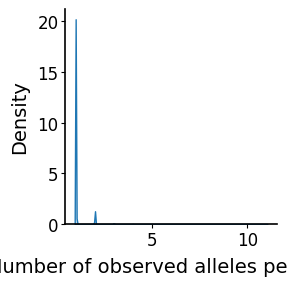

In [29]:
# sns.kdeplot(n_alleles_per_spot_intbc[n_alleles_per_spot_intbc['dataset'] == 'Slide-seq'], x='allele', fill=True, common_norm=True, hue_norm=[0,1])
# sns.kdeplot(n_alleles_per_spot_intbc[n_alleles_per_spot_intbc['dataset'] == 'Slide-tags'], x='allele', fill=True, common_norm=True, hue_norm=[0,1])

with mplscience.style_context():
    h=plt.figure(figsize=(3, 3))
    sns.kdeplot(n_alleles_per_spot_intbc, x='allele', fill=True)
    plt.ylabel("Density")
    plt.xlabel("Number of observed alleles per intBC")
    plt.tight_layout()
    plt.show()

## Extended Data Figure 1d-e, Figure 1c, and Extended Data Figure 2b

In [30]:
ts_umi_to_merge = []
all_allele_tables = []

ts_meta_to_merge = []

for sample_name in tqdm.tqdm(SAMPLES):

    allele_table = pd.read_csv(f'{DATA_DIR}/slideseq/trees/{sample_name}_allele_table.tsv', sep='\t')
    allele_table = allele_table[~allele_table[['r1', 'r2', 'r3']].isna().any(axis=1)]

    character_matrix, _, _ =  cas.pp.convert_alleletable_to_character_matrix(
                                allele_table,
                                mutation_priors=None,
                                collapse_duplicates=False,
                            )

    percent_unique = character_matrix.drop_duplicates().shape[0] / character_matrix.shape[0]
    percent_missing = ((character_matrix == -1).sum(axis=1)).sum() / (character_matrix.shape[1] * character_matrix.shape[0])
    median_umi = allele_table.groupby('cellBC').agg({'UMI': 'sum'}).median()

    ts_meta_to_merge.append(pd.DataFrame([[sample_name, 'slideseq', percent_unique, percent_missing, median_umi]],
                                         columns=['sample_name', 'tech', 'percent_unique', 'percent_missing', 'median_umi'])) 

    per_cell_missing = character_matrix.apply(lambda x: len(x[x==-1]) / len(x), axis=1)
    new_df = pd.DataFrame(allele_table.groupby('cellBC').agg({'UMI': 'sum'}))
    new_df['Sample'] = puck_to_id.loc[sample_name, 'ID']
    new_df['missing'] = np.nan
    new_df['tech'] = 'slideseq'
    new_df.loc[per_cell_missing.index, 'missing'] = per_cell_missing
    
    ts_umi_to_merge.append(new_df.reset_index())

    allele_table['Sample'] = sample_name
    allele_table['dataset'] = 'Slide-seq' 
    all_allele_tables.append(allele_table)

# get slide-tags as well
for experiment in ['Layer1/Puck1', 'Layer2/Puck1', 'Layer3/Puck1', 'Layer3/Puck2', 'Layer4/Puck1']:
    layer, puck = experiment.split("/")
    
    allele_table = pd.read_csv(f'{DATA_DIR}/slidetags/trees/{puck}_{layer}_allele_table.tsv', sep='\t')
    allele_table = allele_table[~allele_table[['r1', 'r2', 'r3']].isna().any(axis=1)]
    
    character_matrix, _, _ =  cas.pp.convert_alleletable_to_character_matrix(
                                allele_table,
                                mutation_priors=None,
                                collapse_duplicates=False,
                            )
        
    percent_unique = character_matrix.drop_duplicates().shape[0] / character_matrix.shape[0]
    percent_missing = ((character_matrix == -1).sum(axis=1)).sum() / (character_matrix.shape[1] * character_matrix.shape[0])
    median_umi = allele_table.groupby('cellBC').agg({'UMI': 'sum'}).median()

    ts_meta_to_merge.append(pd.DataFrame([[sample_name, 'slidetags', percent_unique, percent_missing, median_umi]],
                                         columns=['sample_name', 'tech', 'percent_unique', 'percent_missing', 'median_umi']))  

    per_cell_missing = character_matrix.apply(lambda x: len(x[x==-1]) / len(x), axis=1)
    new_df = pd.DataFrame(allele_table.groupby('cellBC').agg({'UMI': 'sum'}))
    new_df['Sample'] = puck_to_id.loc[f'L{layer[-1]}_{puck}', 'ID']
    new_df['missing'] = np.nan
    new_df['tech'] = 'Slide-tags'
    new_df.loc[per_cell_missing.index, 'missing'] = per_cell_missing
    
    # new_df['cellBC'] = new_df.index.values

    ts_umi_to_merge.append(new_df.reset_index())

    allele_table['Sample'] = experiment
    allele_table['dataset'] = 'Slidetags' 
    all_allele_tables.append(allele_table)


combined_allele_table = pd.concat(all_allele_tables)

ts_meta = pd.concat(ts_meta_to_merge)

ts_umi_distributions = pd.concat(ts_umi_to_merge).reset_index()
ts_umi_distributions.columns = ['null', 'cellBC', 'total_counts', 'Sample', 'missing', 'tech']
ts_umi_distributions['log1p_total_counts'] = np.log1p(ts_umi_distributions['total_counts'])
ts_umi_distributions.head(5)

  0%|          | 0/44 [00:00<?, ?it/s]

Dropping the following intBCs due to lack of diversity with threshold 1.0: []


Processing characters:   0%|          | 0/27 [00:00<?, ?it/s]

  2%|▏         | 1/44 [00:02<01:58,  2.75s/it]

Dropping the following intBCs due to lack of diversity with threshold 1.0: []


...

Dropping the following intBCs due to lack of diversity with threshold 1.0: []


Processing characters:   0%|          | 0/27 [00:00<?, ?it/s]

Dropping the following intBCs due to lack of diversity with threshold 1.0: []


Processing characters:   0%|          | 0/27 [00:00<?, ?it/s]

,null,cellBC,total_counts,Sample,missing,tech,log1p_total_counts
0,0,AAAAACTGAGTGCG,3,S-seq 1,0.666667,slideseq,1.386294
1,1,AAAAAGCAAGATTT,6,S-seq 1,0.666667,slideseq,1.945910
2,2,AAAACACATAACAT,10,S-seq 1,0.444444,slideseq,2.397895
3,3,AAAACAGCATGCCC,2,S-seq 1,0.777778,slideseq,1.098612
4,4,AAAACCAAGCGTGT,4,S-seq 1,0.777778,slideseq,1.609438


### Figure 1c

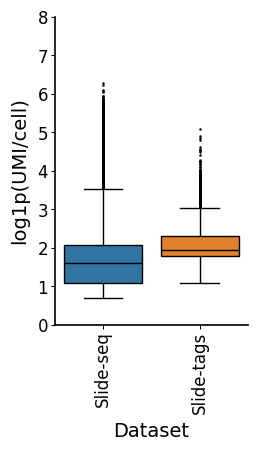

In [31]:
slideseq_umis = combined_allele_table[combined_allele_table['dataset'] == 'Slide-seq'].groupby(['Sample', 'cellBC']).agg({'UMI': 'sum'})
slidetags_umis = combined_allele_table[combined_allele_table['dataset'] == 'Slidetags'].groupby(['Sample', 'cellBC']).agg({'UMI': 'sum'})

slideseq_umis['dataset'] = 'Slide-seq'
slidetags_umis['dataset'] = 'Slide-tags'

combined_data = pd.concat([slideseq_umis[['UMI', 'dataset']], slidetags_umis[['UMI', 'dataset']]])
combined_data['UMI'] = np.log1p(combined_data['UMI'])

with mplscience.style_context():
    h = plt.figure(figsize=(2.5,4))
    sns.boxplot(data=combined_data, x='dataset', y='UMI', hue='dataset', linecolor='black', fliersize=0.8)
    plt.xlabel('Dataset')
    plt.ylabel('log1p(UMI/cell)')
    # plt.yscale('log', base=2)
    plt.xticks(rotation=90)
    plt.ylim(0, 8)
    plt.show()

### Extended Data Figure 2b

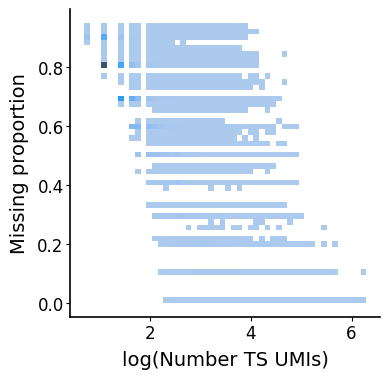

In [32]:
with mplscience.style_context():

    sns.histplot(ts_umi_distributions, x='log1p_total_counts', y='missing', bins=[50, 50])
    plt.xlabel("log(Number TS UMIs)")
    plt.ylabel("Missing proportion")
    # plt.savefig('./figures/missing_vs_umi_capture.pdf')
    plt.show()

### Extended Data Figure 1d

/tmp/ipykernel_904640/2041719414.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  kp_allele_table = pd.read_csv(f"{KPTracer_data}/KPTracer.alleleTable.FINAL.txt", sep='\t')


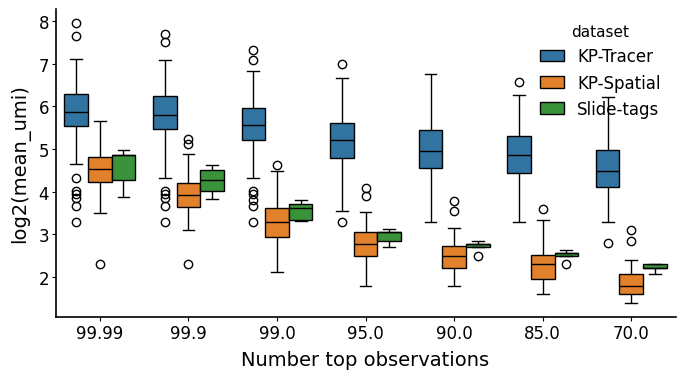

In [36]:
## read in KP Tracer allele table, available from https://zenodo.org/records/5847462
KPTracer_data = f"/path/to/kptracer/data"
kp_allele_table = pd.read_csv(f"{KPTracer_data}/KPTracer.alleleTable.FINAL.txt", sep='\t')

to_merge = []
for _percentile in [70, 85, 90, 95, 99, 99.9, 99.99]:

    mean_umi_per_kp = kp_allele_table.groupby(['Tumor', 'cellBC']).agg({'UMI': 'sum'}).reset_index().groupby('Tumor').agg({'UMI': lambda x: np.percentile(x, _percentile)})
    mean_umi_per_kp['mean_umi'] = np.log1p(mean_umi_per_kp['UMI'])
    mean_umi_per_kp['dataset'] = 'KP-Tracer'
    mean_umi_per_kp['group'] = _percentile
    
    mean_umi_per_slideseq = combined_allele_table[combined_allele_table['dataset'] == 'Slide-seq'].groupby(['Sample', 'cellBC']).agg({'UMI': 'sum'}).reset_index().groupby('Sample').agg({'UMI': lambda x: np.percentile(x, _percentile)})
    mean_umi_per_slideseq['mean_umi'] = np.log1p(mean_umi_per_slideseq['UMI'])
    mean_umi_per_slideseq['dataset'] = 'KP-Spatial'
    mean_umi_per_slideseq['group'] = _percentile

    mean_umi_per_slidetags = combined_allele_table[combined_allele_table['dataset'] == 'Slidetags'].groupby(['Sample', 'cellBC']).agg({'UMI': 'sum'}).reset_index().groupby('Sample').agg({'UMI': lambda x: np.percentile(x, _percentile)})
    mean_umi_per_slidetags['mean_umi'] = np.log1p(mean_umi_per_slidetags['UMI'])
    mean_umi_per_slidetags['dataset'] = 'Slide-tags'
    mean_umi_per_slidetags['group'] = _percentile

    all_means = pd.concat([mean_umi_per_kp, mean_umi_per_slideseq, mean_umi_per_slidetags])
    to_merge.append(all_means)

summary_means = pd.concat(to_merge).reset_index()
summary_means['group'] = summary_means['group'].astype(float)

with mplscience.style_context():
    h=plt.figure(figsize=(8,4))
    sns.boxplot(data=summary_means, x='group', y='mean_umi', hue='dataset', linecolor='black', order=[99.99, 99.9, 99, 95, 90, 85, 70])
    # plt.ylim(0, 50)
    plt.ylabel('log2(mean_umi)')
    plt.xlabel("Number top observations")
    plt.show()

## Extended Data Figure 1g

In [39]:
kptracer_ts_to_merge = []

for tumor in kp_allele_table['Tumor'].unique():
    layer, puck = experiment.split("/")
    
    allele_table = kp_allele_table[kp_allele_table['Tumor'] == tumor]
    
    character_matrix, _, _ =  cas.pp.convert_alleletable_to_character_matrix(
                                allele_table,
                                mutation_priors=None,
                                collapse_duplicates=False,
                            )
    
    percent_unique = character_matrix.drop_duplicates().shape[0] / character_matrix.shape[0]
    percent_missing = ((character_matrix == -1).sum(axis=1)).sum() / (character_matrix.shape[1] * character_matrix.shape[0])
    median_umi = allele_table.groupby('cellBC').agg({'UMI': 'sum'}).median()

    kptracer_ts_to_merge.append(pd.DataFrame([[tumor, percent_unique, percent_missing, median_umi]],
                                         columns=['sample_name', 'percent_unique', 'percent_missing', 'median_umi'])) 

kptracer_ts = pd.concat(kptracer_ts_to_merge)
kptracer_ts['tech'] = '10X'

ts_meta_all = pd.concat([ts_meta, kptracer_ts])
ts_meta_all['capture'] = (1 - ts_meta_all['percent_missing'])

Dropping the following intBCs due to lack of diversity with threshold 1.0: []


Processing characters:   0%|          | 0/30 [00:00<?, ?it/s]

Dropping the following intBCs due to lack of diversity with threshold 1.0: []


Processing characters:   0%|          | 0/30 [00:00<?, ?it/s]

Dropping the following intBCs due to lack of diversity with threshold 1.0: []


...

Processing characters:   0%|          | 0/30 [00:00<?, ?it/s]

Dropping the following intBCs due to lack of diversity with threshold 1.0: []


Processing characters:   0%|          | 0/30 [00:00<?, ?it/s]

Dropping the following intBCs due to lack of diversity with threshold 1.0: []


Processing characters:   0%|          | 0/30 [00:00<?, ?it/s]

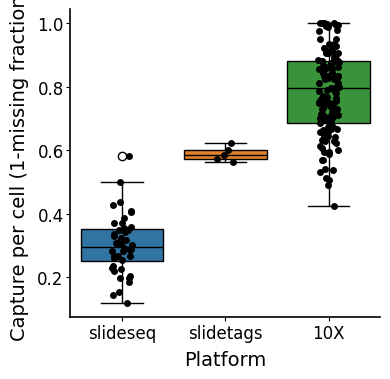

In [40]:
with mplscience.style_context():
    sns.boxplot(ts_meta_all, x='tech', y='capture', hue='tech', linecolor='black', fliersize=None)
    sns.stripplot(ts_meta_all, x='tech', y='capture', color='black')
    plt.xlabel("Platform")
    plt.ylabel("Capture per cell (1-missing fraction)")
    plt.show()

In [43]:
print(f"KPTracer capture (average): {1-kptracer_ts['percent_missing'].mean()}")
print(f"Slideseq capture (average): {1 - ts_meta.loc[ts_meta['tech'] == 'slideseq', 'percent_missing'].mean()}")
print(f"Slidtags capture (average): {1 - ts_meta.loc[ts_meta['tech'] == 'slidetags', 'percent_missing'].mean()}")

KPTracer capture (average): 0.7840878067193394
Slideseq capture (average): 0.3025168832570845
Slidtags capture (average): 0.5891233187706516


### Extended Data Figure 1e

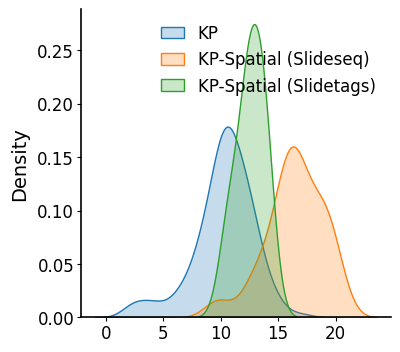

In [44]:
with mplscience.style_context():

    sns.kdeplot(np.log2(kp_allele_table.groupby('Tumor').size()), fill=True, label='KP')
    sns.kdeplot(np.log2(combined_allele_table[combined_allele_table['dataset'] == 'Slide-seq'].groupby('Sample').size()), fill=True, label='KP-Spatial (Slideseq)')
    sns.kdeplot(np.log2(combined_allele_table[combined_allele_table['dataset'] == 'Slidetags'].groupby('Sample').size()), fill=True, label='KP-Spatial (Slidetags)')
    plt.legend()
    plt.show()

### Extended Data Figure 1h

In [47]:
detection_fraction_to_combine = []
for puck_name in tqdm.tqdm(SAMPLES):

    seq_id = puck_to_id.loc[puck_name, 'ID']
    
    spatial_adata = sc.read_h5ad(f'{DATA_DIR}/slideseq/expression/{puck_name}_adata.h5ad')

    allele_table = pd.read_csv(f'{DATA_DIR}/slideseq/trees/{puck_name}_allele_table.tsv', sep='\t')
    allele_table = allele_table[~allele_table[['r1', 'r2', 'r3']].isna().any(axis=1)]

    cellbc_umi = allele_table.groupby('cellBC').agg({'UMI': 'sum'})
    allele_table = allele_table[allele_table['cellBC'].isin(cellbc_umi[cellbc_umi['UMI'] > 5].index.values)]

    fraction_overlap = len(np.intersect1d(spatial_adata.obs_names, allele_table['cellBC'].unique())) / len(spatial_adata.obs_names)
    fraction_tumor_overlap = len(np.intersect1d(spatial_adata[spatial_adata.obs['tumor_id'] != 'non-tumor'].obs_names, allele_table['cellBC'].unique())) / len(spatial_adata[spatial_adata.obs['tumor_id'] != 'non-tumor'].obs_names)

    new_row = pd.DataFrame([[seq_id, fraction_overlap, 'overall', 'slideseq']])
    detection_fraction_to_combine.append(new_row)

    new_row = pd.DataFrame([[seq_id, fraction_tumor_overlap, 'tumor', 'slideseq']])
    detection_fraction_to_combine.append(new_row)
    
# get slide-tags as well
for experiment in ['Layer1/Puck1', 'Layer2/Puck1', 'Layer3/Puck1', 'Layer3/Puck2', 'Layer4/Puck1']:
    layer, puck = experiment.split("/")
    
    allele_table = pd.read_csv(f'{DATA_DIR}/slidetags/trees/{puck}_{layer}_allele_table.tsv', sep='\t')
    allele_table = allele_table[~allele_table[['r1', 'r2', 'r3']].isna().any(axis=1)]


    spatial_adata = sc.read_h5ad(f'{DATA_DIR}/slidetags/expression/adata_slidetags.{layer}.{puck}.h5ad')

    tumor_states = ['AT2-like', 'AT1-like', 'Early EMT', 'Endoderm-like', 'Early gastric', 'Gastric-like', 'High-plasticity cell state', 'Late gastric', 'Neuronal-like', 'Pre-EMT']
    spatial_adata_tumor = spatial_adata[spatial_adata.obs['cell_type'].isin(tumor_states)]

    fraction_overlap = len(np.intersect1d(spatial_adata_tumor.obs_names, allele_table['cellBC'].unique())) / len(spatial_adata_tumor.obs_names)
    
    new_row = pd.DataFrame([[f'{layer}-{puck}', fraction_overlap, 'overall', 'slidetags']])
    detection_fraction_to_combine.append(new_row)

    for tumor, df in spatial_adata_tumor.obs.groupby('tumor_id', observed=False):

        if tumor == 'non-tumor':
            continue
            
        fraction_tumor_overlap = len(np.intersect1d(allele_table['cellBC'].unique(), df.index.values)) / len(df.index.values)
        new_row = pd.DataFrame([[f'{layer}-{puck}', fraction_tumor_overlap, 'tumor', 'slidetags']])
        detection_fraction_to_combine.append(new_row)

detection_summary = pd.concat(detection_fraction_to_combine)
detection_summary.columns = ['Sample', 'FractionCapture', 'Group', 'Tech']

100%|██████████| 44/44 [00:35<00:00,  1.25it/s]


/tmp/ipykernel_904640/2738406705.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(detection_summary, x='FractionCapture', y='Group', ax=ax, fill=True, palette='tab10', linecolor='black', fliersize=0)


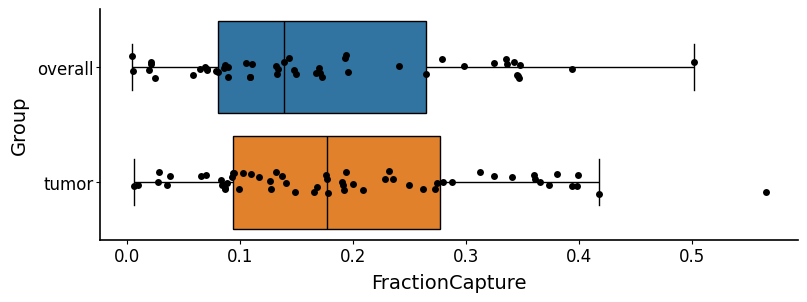

/tmp/ipykernel_904640/2738406705.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(detection_summary[detection_summary['Group'] == 'tumor'], x='FractionCapture', y='Tech', ax=ax, palette='Dark2', linecolor='black', fliersize=0)


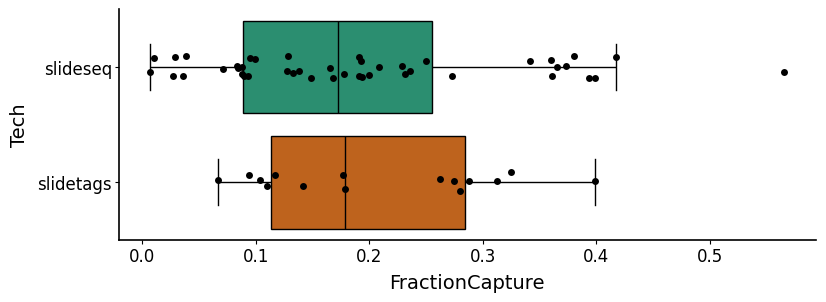

In [50]:

with mplscience.style_context():

    fig = plt.figure(figsize=(9, 3))
    ax = plt.gca()
    sns.boxplot(detection_summary, x='FractionCapture', y='Group', ax=ax, fill=True, palette='tab10', linecolor='black', fliersize=0)
    sns.stripplot(detection_summary, x='FractionCapture', y='Group', ax=ax, color='black')
    plt.show()

    fig = plt.figure(figsize=(9, 3))
    ax = plt.gca()
    sns.boxplot(detection_summary[detection_summary['Group'] == 'tumor'], x='FractionCapture', y='Tech', ax=ax, palette='Dark2', linecolor='black', fliersize=0)
    sns.stripplot(detection_summary[detection_summary['Group'] == 'tumor'], x='FractionCapture', y='Tech', ax=ax, color='black')
    plt.show()